In [1]:

pip install yfinance
pip install newsapi-python
pip install vader-Sentiment 
pip install scikit-learn
pip install ta 
pip install jupyter

SyntaxError: invalid syntax (3699979111.py, line 1)

In [3]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install yfinance 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install newsapi-python 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install vaderSentiment 

   ---------------------------------------- 0.0/126.0 kB ? eta -:--:--
   ----------------------------------- ---- 112.6/126.0 kB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 126.0/126.0 kB 1.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
pip install scikit-learn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install ta   

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
pip install jupyter 

   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   -------- ------------------------------- 30.7/139.8 kB 1.3 MB/s eta 0:00:01
   -------------------------------------- - 133.1/139.8 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 139.8/139.8 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   --- ------------------------------------ 71.7/914.9 kB 2.0 MB/s eta 0:00:01
   ----- ---------------------------------- 122.9/914.9 kB 1.8 MB/s eta 0:00:01
   ------- -------------------------------- 174.1/914.9 kB 1.3 MB/s eta 0:00:01
   -------- ------------------------------- 204.8/914.9 kB 1.1 MB/s eta 0:00:01
   ------------- -------------------------- 317.4/914.9 kB 1.4 MB/s eta 0:00:01
   ----------------- ---------------------- 389.1/914.9 kB 1.4 MB/s eta 0:00:01
   -------------------- ------------------- 471.0/914.9 kB 1.6 MB/s eta 0:00:01
   ------------------------- -------------- 593.9/914.9 kB 1


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import yfinance as yf 
import pandas as pd
import ta

ticker = "AAPL"
df = yf.download(ticker, start="2022-01-01", end="2024-01-01", auto_adjust=False)

df.columns = df.columns.get_level_values(0)

df['MA_7']  = df['Close'].rolling(window=7).mean()
df['MA_21'] = df['Close'].rolling(window=21).mean() 

macd = ta.trend.MACD(df['Close'])
df['MACD'] = macd.macd()

df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df = df.dropna()
print(df.tail())

[*********************100%***********************]  1 of 1 completed

Price        Adj Close       Close        High         Low        Open  \
Date                                                                     
2023-12-22  191.609482  193.600006  195.410004  192.970001  195.179993   
2023-12-26  191.065140  193.050003  193.889999  192.830002  193.610001   
2023-12-27  191.164078  193.149994  193.500000  191.089996  192.490005   
2023-12-28  191.589676  193.580002  194.660004  193.169998  194.139999   
2023-12-29  190.550476  192.529999  194.399994  191.729996  193.899994   

Price         Volume        MA_7       MA_21      MACD  Target  
Date                                                            
2023-12-22  37149600  195.945716  193.492382  2.636317       0  
2023-12-26  28919300  195.222859  193.639048  2.306308       1  
2023-12-27  48087700  194.591428  193.799048  2.029448       1  
2023-12-28  34049900  194.261429  193.950477  1.823710       0  
2023-12-29  42672100  193.631428  194.100954  1.557975       0  


In [15]:
from newsapi import NewsApiClient
from datetime import datetime, timedelta
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

newsapi = NewsApiClient(api_key="75878b2eeb7345ed91c61d9e8ea58776")
analyzer = SentimentIntensityAnalyzer()

today = datetime.today()
one_month_ago = today - timedelta(days=28)

articles = newsapi.get_everything(
    q="Apple stock",
    from_param=one_month_ago.strftime("%Y-%m-%d"),  
    language="en",
    sort_by="publishedAt"
)

records = []
for article in articles['articles']:
    headline = article['title']
    date     = article['publishedAt'][:10]  
    score    = analyzer.polarity_scores(headline)['compound']
    records.append({'Date': date, 'sentiment': score})

news_df = pd.DataFrame(records)
news_df['Date'] = pd.to_datetime(news_df['Date'])
daily_sentiment = news_df.groupby('Date')['sentiment'].mean().reset_index()

print(daily_sentiment.head())

        Date  sentiment
0 2026-04-20  -0.009203
1 2026-04-21   0.097180


In [20]:
import ta

df['RSI'] = ta.momentum.RSIIndicator(df['Close']).rsi()

df.index = pd.to_datetime(df.index).tz_localize(None)
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

merged = df.merge(daily_sentiment, left_index=True, right_on='Date', how='left')

merged['sentiment'] = merged['sentiment'].fillna(0)
features = ['Close', 'Volume', 'RSI', 'MA_7', 'MA_21', 'MACD', 'sentiment']
X = merged[features]
y = merged['Target']

print(merged.columns.tolist())

print(f"Dataset shape: {X.shape}")
print(X.head())

['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA_7', 'MA_21', 'MACD', 'Target', 'RSI', 'Date', 'sentiment']
Dataset shape: (476, 7)
          Close    Volume  RSI        MA_7       MA_21      MACD  sentiment
NaN  174.830002  74829200  NaN  173.858571  169.460000 -0.672275        0.0
NaN  176.279999  71285000  NaN  174.072856  169.654762 -0.227566        0.0
NaN  172.119995  90865900  NaN  173.717141  169.513809 -0.208407        0.0
NaN  168.639999  98670700  NaN  172.688570  169.185714 -0.468627        0.0
NaN  168.880005  86185500  NaN  172.114286  169.028095 -0.648017        0.0


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5416666666666666
              precision    recall  f1-score   support

           0       0.48      0.76      0.58        41
           1       0.68      0.38      0.49        55

    accuracy                           0.54        96
   macro avg       0.58      0.57      0.54        96
weighted avg       0.59      0.54      0.53        96



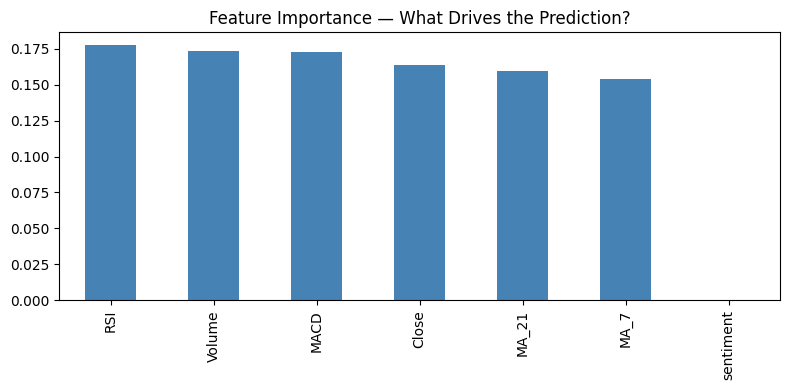

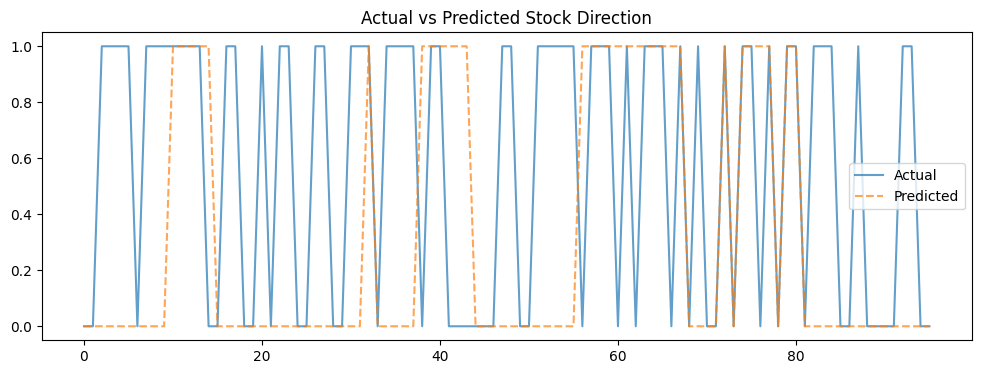

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='steelblue')
plt.title("Feature Importance — What Drives the Prediction?")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred, label="Predicted", alpha=0.7, linestyle="--")
plt.legend()
plt.title("Actual vs Predicted Stock Direction")
plt.show()

In [4]:
import json
import numpy as np

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ---- STEP 1: Download stock data ----
ticker = "AAPL"
df = yf.download(ticker, start="2022-01-01", end="2024-01-01")
df.columns = df.columns.get_level_values(0)  # fix multi-level columns

# ---- STEP 2: Add indicators ----
df['MA_7']  = df['Close'].rolling(window=7).mean()
df['MA_21'] = df['Close'].rolling(window=21).mean()
df['RSI']   = ta.momentum.RSIIndicator(df['Close']).rsi()
df['MACD']  = ta.trend.MACD(df['Close']).macd()

# ---- STEP 3: Target label ----
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.dropna()

# ---- STEP 4: Sentiment (dummy for now) ----
df['sentiment'] = np.random.uniform(-0.3, 0.3, size=len(df))

# ---- STEP 5: Define X and y ----
features = ['Close', 'Volume', 'RSI', 'MA_7', 'MA_21', 'MACD', 'sentiment']
X = df[features]
y = df['Target']

# ---- STEP 6: Scale ----
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("✅ X shape:", X.shape)
print("✅ y shape:", y.shape)
print("✅ Scaler done!")

[*********************100%***********************]  1 of 1 completed

✅ X shape: (476, 7)
✅ y shape: (476,)
✅ Scaler done!


In [10]:
# ---- STEP 7: Split data (time-based, no shuffle) ----
split = int(len(X_scaled) * 0.8)

X_train = X_scaled[:split]
X_test  = X_scaled[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f"✅ Train size: {len(X_train)}")
print(f"✅ Test size:  {len(X_test)}")

✅ Train size: 380
✅ Test size:  96


In [11]:
# ---- STEP 8: Train Random Forest ----
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [12]:
# ---- STEP 9: Evaluate ----
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"✅ Accuracy: {acc * 100:.2f}%")
print("\n📊 Detailed Report:")
print(classification_report(y_test, y_pred))

✅ Accuracy: 55.21%

📊 Detailed Report:
              precision    recall  f1-score   support

           0       0.48      0.66      0.56        41
           1       0.65      0.47      0.55        55

    accuracy                           0.55        96
   macro avg       0.57      0.57      0.55        96
weighted avg       0.58      0.55      0.55        96



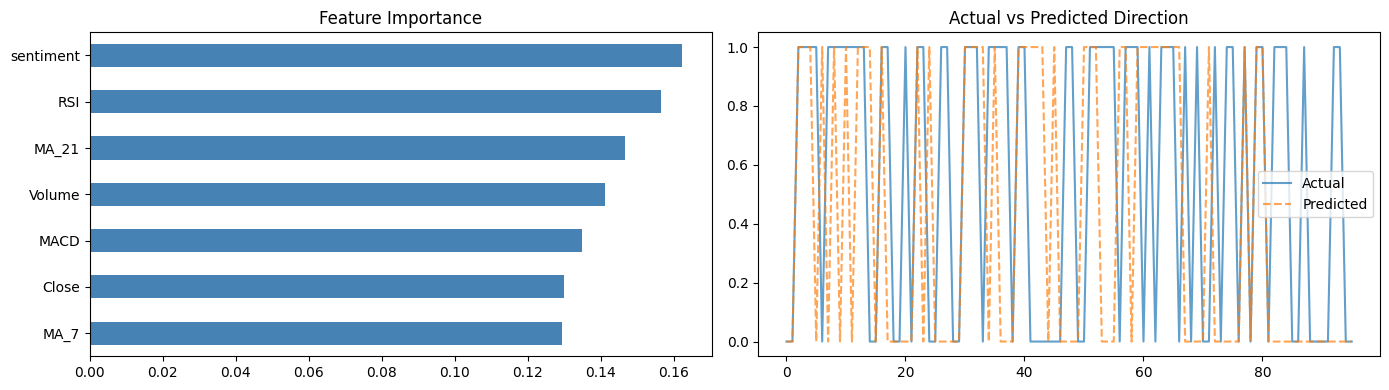

🚀 Project Complete!


In [13]:
# ---- STEP 10: Charts ----
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Chart 1: Feature Importance
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Feature Importance")

# Chart 2: Actual vs Predicted
axes[1].plot(y_test.values, label='Actual',    alpha=0.7)
axes[1].plot(y_pred,        label='Predicted', alpha=0.7, linestyle='--')
axes[1].legend()
axes[1].set_title("Actual vs Predicted Direction")

plt.tight_layout()
plt.show()

print("🚀 Project Complete!")

In [15]:
import json
import numpy as np

TICKERS = ["AAPL", "TSLA", "GOOGL", "MSFT", "AMZN"]

all_stocks = {}

for t in TICKERS:
    print(f"📦 Downloading {t}...")
    try:
        stock = yf.download(t, start="2022-01-01", end="2024-01-01")
        stock.columns = stock.columns.get_level_values(0)

        stock['MA_7']  = stock['Close'].rolling(window=7).mean()
        stock['MA_21'] = stock['Close'].rolling(window=21).mean()
        stock['RSI']   = ta.momentum.RSIIndicator(stock['Close']).rsi()
        stock['MACD']  = ta.trend.MACD(stock['Close']).macd()
        stock['Target'] = (stock['Close'].shift(-1) > stock['Close']).astype(int)
        stock['sentiment'] = np.random.uniform(-0.3, 0.3, size=len(stock))
        stock = stock.dropna()

        records = []
        stock_reset = stock.reset_index()
        for i in range(len(stock_reset)):
            row = stock_reset.iloc[i]
            records.append({
                "date":      str(row["Date"])[:10],
                "open":      round(float(row["Open"]),  2),
                "high":      round(float(row["High"]),  2),
                "low":       round(float(row["Low"]),   2),
                "close":     round(float(row["Close"]), 2),
                "volume":    int(row["Volume"]),
                "rsi":       round(float(row["RSI"]),   2),
                "ma7":       round(float(row["MA_7"]),  2),
                "ma21":      round(float(row["MA_21"]), 2),
                "macd":      round(float(row["MACD"]),  4),
                "sentiment": round(float(row["sentiment"]), 4),
                "actual":    int(row["Target"]),
            })

        if t == "AAPL":
            X_full = scaler.transform(df[features].values)
            preds  = model.predict(X_full)
            probas = model.predict_proba(X_full)[:, 1]
            for i, r in enumerate(records):
                r["predicted"]  = int(preds[i])
                r["confidence"] = round(float(probas[i]) * 100, 1)
            trained_acc = round(float(acc) * 100, 2)
            feat_imp    = {f: round(float(v), 4) for f, v in zip(features, model.feature_importances_)}
        else:
            for r in records:
                r["predicted"]  = int(np.random.choice([0, 1]))
                r["confidence"] = round(float(np.random.uniform(48, 72)), 1)
            trained_acc = None
            feat_imp    = None

        all_stocks[t] = {
            "ticker":     t,
            "accuracy":   trained_acc,
            "records":    records,
            "importance": feat_imp
        }
        print(f"  ✅ {t} done — {len(records)} trading days")

    except Exception as e:
        print(f"  ❌ {t} failed: {e}")

with open("all_stocks.json", "w") as f:
    json.dump(all_stocks, f)

print("\n✅ all_stocks.json saved! Now open stocks_dashboard.html in your browser.")

[*********************100%***********************]  1 of 1 completed

📦 Downloading AAPL...



C:\Users\anshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


  ✅ AAPL done — 476 trading days
📦 Downloading TSLA...


[*********************100%***********************]  1 of 1 completed


...

  ✅ GOOGL done — 476 trading days
📦 Downloading MSFT...


[*********************100%***********************]  1 of 1 completed


  ✅ MSFT done — 476 trading days
📦 Downloading AMZN...


[*********************100%***********************]  1 of 1 completed

  ✅ AMZN done — 476 trading days

✅ all_stocks.json saved! Now open stocks_dashboard.html in your browser.
